# Detection Statistique (Clustering DBSCAN)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

In [26]:
import pandas as pd
df = pd.read_csv("farm_array_elec_clearsky.csv")
print(df.columns.tolist())
print(df.head())

['Unnamed: 0', 'measured_on', 'inv_01_dc_current', 'inv_01_dc_voltage', 'inv_01_ac_current', 'inv_01_ac_voltage', 'inv_01_ac_power', 'inv_02_dc_current', 'inv_02_dc_voltage', 'inv_02_ac_current', 'inv_02_ac_voltage', 'inv_02_ac_power', 'inv_03_dc_current', 'inv_03_dc_voltage', 'inv_03_ac_current', 'inv_03_ac_voltage', 'inv_03_ac_power', 'inv_05_dc_current', 'inv_05_ac_current', 'inv_05_ac_voltage', 'inv_05_ac_power', 'inv_06_dc_current', 'inv_06_dc_voltage', 'inv_06_ac_current', 'inv_06_ac_voltage', 'inv_06_ac_power', 'inv_07_dc_current', 'inv_07_dc_voltage', 'inv_07_ac_current', 'inv_07_ac_voltage', 'inv_07_ac_power', 'inv_08_dc_current', 'inv_08_dc_voltage', 'inv_08_ac_current', 'inv_08_ac_voltage', 'inv_08_ac_power', 'inv_09_dc_current', 'inv_09_dc_voltage', 'inv_09_ac_current', 'inv_09_ac_voltage', 'inv_09_ac_power', 'inv_10_dc_current', 'inv_10_dc_voltage', 'inv_10_ac_current', 'inv_10_ac_voltage', 'inv_10_ac_power', 'inv_11_dc_current', 'inv_11_dc_voltage', 'inv_11_ac_current', '

## Configuration

In [27]:
# Paramètres de détection
ANOMALY_THRESHOLD = 0.15  # 15% d'écart minimum vs référence
MIN_DURATION = 30  # Minutes consécutives minimum
RECURRENCE_THRESHOLD = 0.60  # 60% de jours avec anomalie = motif récurrent
MIN_POWER_THRESHOLD = 100  # W - Seuil minimum pour analyse (évite nuit)

# Paramètres DBSCAN
DBSCAN_EPS_DAYS = 12  # Tolérance temporelle (jours)
DBSCAN_MIN_SAMPLES = 6  # Minimum de jours pour former un cluster
DBSCAN_EPS_HOURS = 0.5  # Tolérance horaire (heures)

# Paramètres saisonniers
SEASONS = {
    'Winter': [12, 1, 2],
    'Spring': [3, 4, 5],
    'Summer': [6, 7, 8],
    'Autumn': [9, 10, 11]
}

print("🔍 Chargement des données prétraitées...")

🔍 Chargement des données prétraitées...


## Chargement et préparation des données

In [28]:
df = pd.read_csv("farm_array_elec_clearsky.csv")

# Renommage de la colonne temporelle
if 'measured_on' in df.columns:
    df['timestamp'] = pd.to_datetime(df['measured_on'])
elif 'timestamp' not in df.columns:
    raise ValueError("Aucune colonne temporelle trouvée (measured_on ou timestamp)")

df = df.sort_values('timestamp').reset_index(drop=True)

# Détection des onduleurs (colonnes inv_XX_ac_power)
power_cols = [c for c in df.columns if c.endswith('_ac_power') and c.startswith('inv_')]
inverter_ids = [c.replace('_ac_power', '') for c in power_cols]

print(f"✓ {len(df)} lignes chargées")
print(f"✓ {len(power_cols)} onduleurs détectés: {inverter_ids[:5]}{'...' if len(inverter_ids) > 5 else ''}")
print(f"✓ Période: {df['timestamp'].min()} → {df['timestamp'].max()}")

if len(power_cols) == 0:
    raise ValueError("❌ Aucune colonne *_ac_power trouvée!")

# Filtrage des valeurs aberrantes et nettoyage
for col in power_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    df[col] = df[col].clip(lower=0)  # Pas de puissance négative


✓ 721067 lignes chargées
✓ 23 onduleurs détectés: ['inv_01', 'inv_02', 'inv_03', 'inv_05', 'inv_06']...
✓ Période: 2017-11-01 00:00:00 → 2024-11-01 23:55:00


## Calcul de la référence (A corriger ! )

In [29]:
# Stratégie : utiliser le 95e percentile mobile de la production totale
# comme proxy du "clearsky" (production sans ombrage)

df['total_power'] = df[power_cols].sum(axis=1)

# Calcul du percentile 95 sur fenêtre glissante de 7 jours par heure
df['hour'] = df['timestamp'].dt.hour
df['date'] = df['timestamp'].dt.date
df['day_of_year'] = df['timestamp'].dt.dayofyear

# Percentile 95 par heure et période de l'année (fenêtre ±7 jours)
reference_powers = {}
for hour in range(24):
    hour_data = df[df['hour'] == hour]
    if len(hour_data) > 0:
        # Percentile 95 comme référence "ciel clair"
        p95 = hour_data.groupby('day_of_year')['total_power'].quantile(0.95)
        # Lissage avec moyenne mobile
        p95_smooth = p95.rolling(window=7, center=True, min_periods=1).mean()
        reference_powers[hour] = p95_smooth

# Application de la référence
df['expected_power'] = 0.0
for hour, ref_series in reference_powers.items():
    mask = df['hour'] == hour
    df.loc[mask, 'expected_power'] = df.loc[mask, 'day_of_year'].map(ref_series).fillna(0)

print(f"✓ Référence théorique calculée (percentile 95 par heure)")


✓ Référence théorique calculée (percentile 95 par heure)


- On calcule une référence de production par heure basée sur le *95e percentile* de la production totale (fenêtre journalière ±7 jours), puis on lisse la série.
- Cette référence représente une estimation robuste d'une production sans ombrage (proxy « clearsky ») en supprimant l'effet des valeurs basses fréquentes.

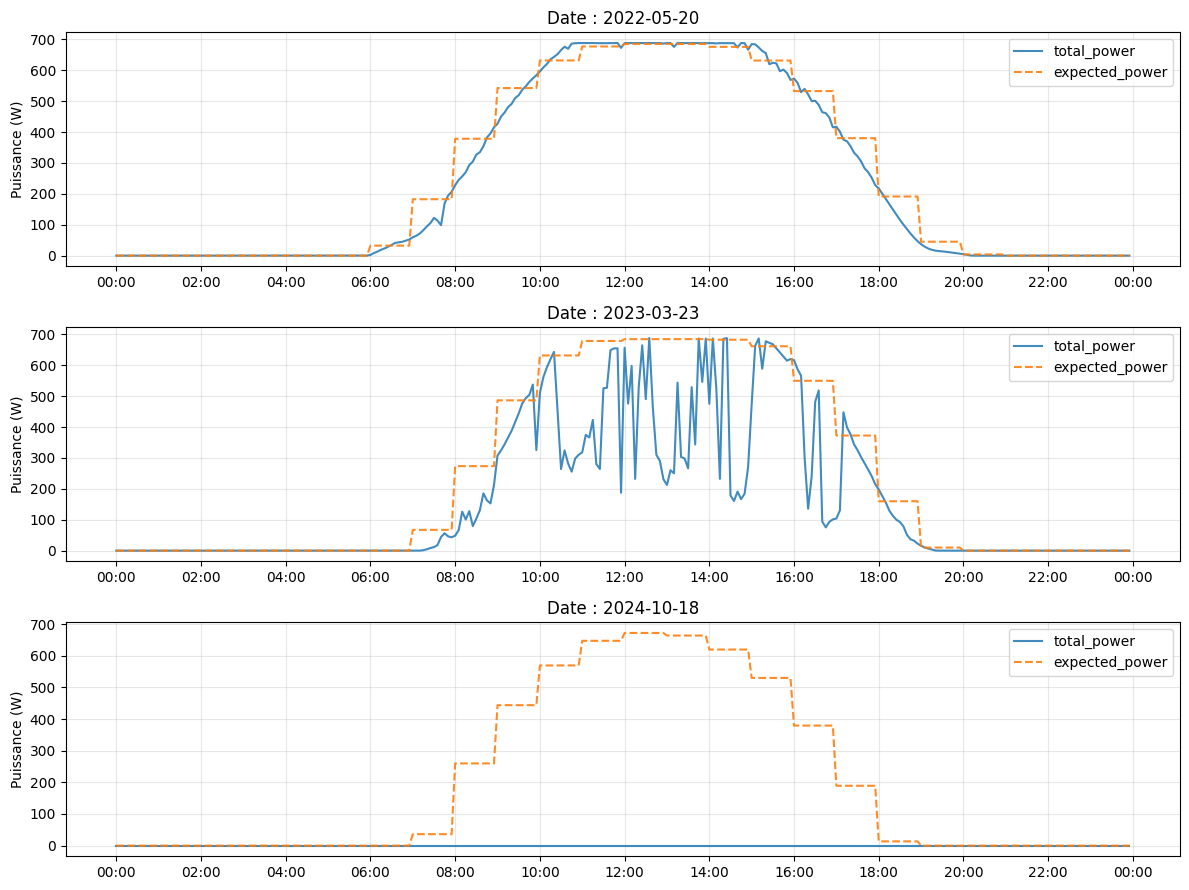

In [30]:
# Tracer `expected_power` vs `total_power` pour quelques jours représentatifs.
import matplotlib.dates as mdates

# Préparation des statistiques journalières
daily = df.groupby('date').agg(
    daily_total=('total_power', 'sum'),
    max_expected=('expected_power', 'max')
).reset_index()

# Conserver uniquement les jours avec une preuve de journée (expected > MIN_POWER_THRESHOLD)
day_candidates = daily[daily['max_expected'] > MIN_POWER_THRESHOLD]

if len(day_candidates) == 0:
    candidate_dates = daily['date'].unique()[:3].tolist()
else:
    sd = day_candidates.sort_values('daily_total')
    i_mid = len(sd) // 2
    candidate_dates = [sd['date'].iloc[-1], sd['date'].iloc[i_mid], sd['date'].iloc[0]]

# Uniques et jusqu'à 3
seen = []
for d in candidate_dates:
    if d not in seen:
        seen.append(d)
selected_days = seen[:3]

if len(selected_days) == 0:
    print("⚠️ Aucun jour représentatif trouvé pour le tracé.")
else:
    fig, axes = plt.subplots(len(selected_days), 1, figsize=(12, 3 * len(selected_days)), sharex=False)
    if len(selected_days) == 1:
        axes = [axes]

    for ax, d in zip(axes, selected_days):
        day_df = df[df['date'] == d].copy()
        if len(day_df) == 0:
            ax.text(0.5, 0.5, "Aucune donnée", ha='center')
            continue

        ax.plot(day_df['timestamp'], day_df['total_power'], label='total_power', color='tab:blue', alpha=0.85)
        ax.plot(day_df['timestamp'], day_df['expected_power'], label='expected_power', color='tab:orange', linestyle='--', alpha=0.9)
        ax.set_title(f"Date : {d}")
        ax.set_ylabel('Puissance (W)')
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.grid(alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

## Etape 1 : Détection des outliers par ondulateurs 

In [31]:
# Calcul du ratio de chaque onduleur par rapport à la production attendue
df_ratios = df[['timestamp', 'expected_power', 'hour', 'date', 'day_of_year']].copy()

for inv_id, power_col in zip(inverter_ids, power_cols):
    # Ratio normalisé : puissance onduleur / (production totale attendue / nb onduleurs)
    expected_inv = df['expected_power'] / len(power_cols)
    ratio = df[power_col] / (expected_inv + 1e-6)
    df_ratios[f'ratio_{inv_id}'] = ratio.clip(0, 1.5)

# Identification de l'onduleur de référence (meilleur performer moyen)
ratio_cols = [c for c in df_ratios.columns if c.startswith('ratio_')]
mask_daylight = df_ratios['expected_power'] > MIN_POWER_THRESHOLD
mean_ratios = df_ratios.loc[mask_daylight, ratio_cols].mean()
ref_inverter = mean_ratios.idxmax()

print(f"✓ Onduleur de référence: {ref_inverter.replace('ratio_', '')} (ratio moyen: {mean_ratios.max():.3f})")

# Détection des anomalies
anomalies = []
for ratio_col in ratio_cols:
    if ratio_col == ref_inverter:
        continue
    
    inv_id = ratio_col.replace('ratio_', '')
    
    # Déviation par rapport à la référence
    deviation = (df_ratios[ref_inverter] - df_ratios[ratio_col]).clip(0, 1.0)
    
    # Masque d'anomalie
    mask_anomaly = (
        (deviation > ANOMALY_THRESHOLD) & 
        (df_ratios['expected_power'] > MIN_POWER_THRESHOLD)
    )
    
    # Regroupement en séquences continues
    df_ratios['anomaly'] = mask_anomaly
    df_ratios['anomaly_group'] = (df_ratios['anomaly'] != df_ratios['anomaly'].shift()).cumsum()
    
    for group_id, group in df_ratios[df_ratios['anomaly']].groupby('anomaly_group'):
        duration_minutes = len(group) * 5  # Intervalle de 5 minutes
        
        if duration_minutes >= MIN_DURATION:
            anomalies.append({
                'inverter_id': inv_id,
                'start_time': group['timestamp'].iloc[0],
                'end_time': group['timestamp'].iloc[-1],
                'duration_min': duration_minutes,
                'avg_deviation': deviation.loc[group.index].mean(),
                'max_deviation': deviation.loc[group.index].max()
            })

df_anomalies = pd.DataFrame(anomalies)

if len(df_anomalies) == 0:
    print("⚠️  Aucune anomalie détectée avec les seuils actuels")
    print(f"💡 Essayez de réduire ANOMALY_THRESHOLD (actuellement {ANOMALY_THRESHOLD})")
else:
    print(f"✓ {len(df_anomalies)} anomalies détectées (durée ≥ {MIN_DURATION} min)")
    print(f"✓ {df_anomalies['inverter_id'].nunique()} onduleurs concernés")


✓ Onduleur de référence: inv_20 (ratio moyen: 0.712)
✓ 26044 anomalies détectées (durée ≥ 30 min)
✓ 22 onduleurs concernés


- `df_anomalies` contient les périodes où un onduleur est significativement en dessous du comportement attendu (seuil `ANOMALY_THRESHOLD`, durée ≥ `MIN_DURATION`).
- Un grand nombre d'anomalies courtes peut indiquer du bruit (nuages transitoires, capteurs, erreurs de données).
- Des anomalies longues et récurrentes suggèrent un ombrage récurrent ou un problème matériel.


## Etape 2 : Profils horaires (shadox profiles)

In [32]:
# Initialisation AVANT la condition
df_profiles = pd.DataFrame()
profiles = []

if len(df_anomalies) > 0:
    # Extraction des caractéristiques temporelles
    df_anomalies['date'] = df_anomalies['start_time'].dt.date
    df_anomalies['hour'] = df_anomalies['start_time'].dt.hour
    df_anomalies['minute'] = df_anomalies['start_time'].dt.minute
    df_anomalies['time_decimal'] = df_anomalies['hour'] + df_anomalies['minute']/60
    df_anomalies['month'] = df_anomalies['start_time'].dt.month
    df_anomalies['day_of_year'] = df_anomalies['start_time'].dt.dayofyear
    
    # Attribution des saisons
    def get_season(month):
        for season, months in SEASONS.items():
            if month in months:
                return season
        return 'Unknown'
    
    df_anomalies['season'] = df_anomalies['month'].apply(get_season)
    
    # Calcul de la récurrence
    for (inv, season), group in df_anomalies.groupby(['inverter_id', 'season']):
        total_days = group['date'].nunique()
        
        # Analyse par heure
        for hour in range(24):
            hour_mask = (group['hour'] == hour)
            if hour_mask.sum() > 0:
                recurrence_days = group[hour_mask]['date'].nunique()
                recurrence_rate = recurrence_days / total_days
                
                if recurrence_rate >= RECURRENCE_THRESHOLD:
                    profiles.append({
                        'inverter_id': inv,
                        'season': season,
                        'hour': hour,
                        'recurrence_days': recurrence_days,
                        'total_days': total_days,
                        'recurrence_rate': recurrence_rate,
                        'avg_loss_pct': group[hour_mask]['avg_deviation'].mean() * 100
                    })
    
    df_profiles = pd.DataFrame(profiles)
    print(f"✓ {len(df_profiles)} profils horaires récurrents identifiés")
    
    if len(df_profiles) > 0:
        print("\n📊 Top 5 des profils d'ombrage:")
        display = df_profiles.nlargest(5, 'avg_loss_pct')[
            ['inverter_id', 'season', 'hour', 'recurrence_rate', 'avg_loss_pct']
        ]
        for _, row in display.iterrows():
            print(f"  • {row['inverter_id']} | {row['season']} | {row['hour']:02d}h | "
                  f"Récurrence: {row['recurrence_rate']:.1%} | Perte: {row['avg_loss_pct']:.1f}%")


✓ 62 profils horaires récurrents identifiés

📊 Top 5 des profils d'ombrage:
  • inv_11 | Spring | 15h | Récurrence: 100.0% | Perte: 94.8%
  • inv_23 | Spring | 08h | Récurrence: 60.0% | Perte: 93.1%
  • inv_11 | Spring | 16h | Récurrence: 100.0% | Perte: 86.8%
  • inv_14 | Summer | 07h | Récurrence: 90.0% | Perte: 85.0%
  • inv_17 | Summer | 07h | Récurrence: 88.5% | Perte: 83.5%




**Que contient `df_profiles` ?**
- Profils horaires récurrents d'ombrage par onduleur et saison (heure, taux de récurrence, perte moyenne en %).

**Interprétation**
- Une forte `recurrence_rate` (≥ `RECURRENCE_THRESHOLD`) indique un ombrage régulier à une heure donnée (ex. arbre, obstruction structurelle).
- `avg_loss_pct` permet d'évaluer l'impact énergétique moyen du profil.


## Etape 3 : Clustering saisonier (DBSCAN)

In [33]:
clusters_results = []

if len(df_profiles) > 0:
    for (inv, season), group_profiles in df_profiles.groupby(['inverter_id', 'season']):
        # Extraction des anomalies pour cet onduleur/saison
        mask = (df_anomalies['inverter_id'] == inv) & (df_anomalies['season'] == season)
        season_anomalies = df_anomalies[mask].copy()
        
        if len(season_anomalies) < DBSCAN_MIN_SAMPLES:
            continue
        
        # Features pour DBSCAN
        X = season_anomalies[['day_of_year', 'time_decimal']].values
        
        # Normalisation avec pondération temporelle
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Application DBSCAN
        clustering = DBSCAN(
            eps=0.9,
            min_samples=DBSCAN_MIN_SAMPLES,
            metric='euclidean'
        ).fit(X_scaled)
        
        season_anomalies['cluster'] = clustering.labels_
        
        # Analyse des clusters (exclut bruit: -1)
        for cluster_id in set(clustering.labels_):
            if cluster_id == -1:
                continue
            
            cluster_data = season_anomalies[season_anomalies['cluster'] == cluster_id]
            
            clusters_results.append({
                'inverter_id': inv,
                'season': season,
                'cluster_id': cluster_id,
                'start_date': cluster_data['start_time'].min().date(),
                'end_date': cluster_data['start_time'].max().date(),
                'n_days': cluster_data['date'].nunique(),
                'shadow_start_hour': cluster_data['time_decimal'].min(),
                'shadow_end_hour': cluster_data['time_decimal'].max(),
                'avg_loss_pct': cluster_data['avg_deviation'].mean() * 100,
                'max_loss_pct': cluster_data['max_deviation'].max() * 100
            })

df_clusters = pd.DataFrame(clusters_results)

if len(df_clusters) == 0:
    print("⚠️  Aucun cluster identifié")
    print("💡 Suggestions:")
    print(f"  - Réduire ANOMALY_THRESHOLD (actuellement {ANOMALY_THRESHOLD})")
    print(f"  - Réduire RECURRENCE_THRESHOLD (actuellement {RECURRENCE_THRESHOLD})")
    print(f"  - Réduire DBSCAN_MIN_SAMPLES (actuellement {DBSCAN_MIN_SAMPLES})")
else:
    print(f"✓ {len(df_clusters)} clusters d'ombrage identifiés")


✓ 85 clusters d'ombrage identifiés


- DBSCAN groupe des anomalies proches en jour de l'année et heure pour identifier des motifs d'ombrage cohérents (clusters), en excluant le bruit (-1).
- Un cluster indique un motif spatial/temporal répété (ex. ombre d'un mat à certaines périodes).
- `n_days`, `shadow_start_hour`, `avg_loss_pct` donnent l'importance et la fenêtre horaire du problème.


## Etape 4 : Shadow story - rapport final

In [34]:
if len(df_clusters) > 0:
    # Formatage des heures
    def format_hour(decimal_hour):
        h = int(decimal_hour)
        m = int((decimal_hour - h) * 60)
        return f"{h:02d}h{m:02d}"
    
    df_clusters['shadow_period'] = (
        df_clusters['shadow_start_hour'].apply(format_hour) + 
        ' → ' + 
        df_clusters['shadow_end_hour'].apply(format_hour)
    )
    
    # Tri par impact
    df_shadow_story = df_clusters.sort_values('avg_loss_pct', ascending=False)
    
    # Export
    df_shadow_story.to_csv('shadow_story.csv', index=False)
    print("✓ Shadow Story exportée → shadow_story.csv")
    
    print("\n🎯 SHADOW STORY - Top 10 des ombrages critiques:")
    print("="*70)
    for idx, row in df_shadow_story.head(10).iterrows():
        print(f"  {row['inverter_id']:>10} | {row['season']:>6} | {row['shadow_period']} | "
              f"{row['n_days']:3d} jours | Perte: {row['avg_loss_pct']:5.1f}%")
    
    # Visualisations
    
    print("\n📈 Génération des visualisations...")
    
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
    
    # Plot 1: Heatmap récurrence horaire
    if len(df_profiles) > 0:
        ax1 = fig.add_subplot(gs[0, :2])
        pivot = df_profiles.pivot_table(
            values='recurrence_rate',
            index='inverter_id',
            columns='hour',
            aggfunc='mean'
        )
        sns.heatmap(pivot, cmap='YlOrRd', annot=False, fmt='.0%',
                    cbar_kws={'label': 'Taux de récurrence'}, ax=ax1)
        ax1.set_title('Récurrence Horaire des Ombrages par Onduleur', fontweight='bold')
        ax1.set_xlabel('Heure de la journée')
        ax1.set_ylabel('Onduleur')
    
    # Plot 2: Distribution des pertes
    ax2 = fig.add_subplot(gs[0, 2])
    ax2.hist(df_clusters['avg_loss_pct'], bins=20, color='coral', edgecolor='black', alpha=0.7)
    ax2.axvline(df_clusters['avg_loss_pct'].median(), color='red', 
                linestyle='--', linewidth=2, label=f"Médiane: {df_clusters['avg_loss_pct'].median():.1f}%")
    ax2.set_title('Distribution des Pertes', fontweight='bold')
    ax2.set_xlabel('Perte moyenne (%)')
    ax2.set_ylabel('Nombre de clusters')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Plot 3: Timeline des périodes d'ombrage
    ax3 = fig.add_subplot(gs[1, :])
    colors = plt.cm.Set3(np.linspace(0, 1, len(df_clusters)))
    for idx, (i, row) in enumerate(df_clusters.iterrows()):
        start = pd.Timestamp(row['start_date'])
        end = pd.Timestamp(row['end_date'])
        ax3.barh(row['inverter_id'], (end - start).days, left=start, 
                height=0.6, color=colors[idx], alpha=0.8, edgecolor='black')
    ax3.set_title('Périodes d\'Ombrage Détectées (Timeline)', fontweight='bold')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Onduleur')
    ax3.grid(axis='x', alpha=0.3)
    
    # Plot 4: Scatter clustering (jour vs heure)
    if 'cluster' in df_anomalies.columns:
        ax4 = fig.add_subplot(gs[2, 0])
        scatter_data = df_anomalies[df_anomalies['cluster'] != -1]
        if len(scatter_data) > 0:
            scatter = ax4.scatter(scatter_data['day_of_year'], scatter_data['time_decimal'],
                                c=scatter_data['cluster'], cmap='tab10', alpha=0.6, s=15)
            ax4.set_title('Résultats DBSCAN', fontweight='bold')
            ax4.set_xlabel('Jour de l\'année')
            ax4.set_ylabel('Heure (décimale)')
            ax4.grid(alpha=0.3)
    
    # Plot 5: Répartition saisonnière
    ax5 = fig.add_subplot(gs[2, 1])
    season_counts = df_clusters['season'].value_counts()
    ax5.bar(season_counts.index, season_counts.values, color='steelblue', edgecolor='black')
    ax5.set_title('Répartition Saisonnière', fontweight='bold')
    ax5.set_xlabel('Saison')
    ax5.set_ylabel('Nombre de clusters')
    ax5.grid(axis='y', alpha=0.3)
    
    # Plot 6: Top onduleurs affectés
    ax6 = fig.add_subplot(gs[2, 2])
    inv_counts = df_clusters['inverter_id'].value_counts().head(10)
    ax6.barh(range(len(inv_counts)), inv_counts.values, color='indianred', edgecolor='black')
    ax6.set_yticks(range(len(inv_counts)))
    ax6.set_yticklabels(inv_counts.index)
    ax6.set_title('Top 10 Onduleurs Affectés', fontweight='bold')
    ax6.set_xlabel('Nombre de clusters')
    ax6.invert_yaxis()
    ax6.grid(axis='x', alpha=0.3)
    
    plt.suptitle('Détection d\'Ombrage PV - Analyse DBSCAN', 
                 fontsize=16, fontweight='bold', y=0.995)
    plt.savefig('shadow_detection_results.png', dpi=150, bbox_inches='tight')
    print("✓ Visualisations sauvegardées → shadow_detection_results.png")
    plt.close()

print("\n" + "="*70)
print("✅ ANALYSE TERMINÉE")
print("="*70)

if len(df_clusters) > 0:
    total_loss = df_clusters['avg_loss_pct'].sum()
    print(f"\n📊 RÉSUMÉ:")
    print(f"  • {len(df_clusters)} périodes d'ombrage détectées")
    print(f"  • {df_clusters['inverter_id'].nunique()} onduleurs affectés")
    print(f"  • Perte moyenne par cluster: {df_clusters['avg_loss_pct'].mean():.1f}%")
    print(f"  • Perte maximale observée: {df_clusters['max_loss_pct'].max():.1f}%")
else:
    print("\n⚠️  Aucun ombrage détecté. Vérifiez les paramètres ou la qualité des données.")

✓ Shadow Story exportée → shadow_story.csv

🎯 SHADOW STORY - Top 10 des ombrages critiques:
      inv_17 | Autumn | 08h00 → 08h00 |   9 jours | Perte:  89.6%
      inv_17 | Summer | 07h00 → 07h00 |   9 jours | Perte:  89.5%
      inv_14 | Summer | 10h39 → 16h55 |   8 jours | Perte:  85.6%
      inv_14 | Summer | 07h00 → 10h05 | 106 jours | Perte:  83.8%
      inv_08 | Summer | 14h20 → 15h39 |   4 jours | Perte:  67.7%
      inv_17 | Summer | 07h00 → 10h45 |  15 jours | Perte:  67.3%
      inv_10 | Summer | 07h00 → 15h30 |  60 jours | Perte:  62.6%
      inv_05 | Autumn | 12h50 → 17h49 |   6 jours | Perte:  62.3%
      inv_14 | Spring | 07h00 → 18h25 |  60 jours | Perte:  51.4%
      inv_06 | Autumn | 07h00 → 18h10 | 245 jours | Perte:  50.9%

📈 Génération des visualisations...
✓ Visualisations sauvegardées → shadow_detection_results.png

✅ ANALYSE TERMINÉE

📊 RÉSUMÉ:
  • 85 périodes d'ombrage détectées
  • 22 onduleurs affectés
  • Perte moyenne par cluster: 34.3%
  • Perte maximale ob

- `shadow_story.csv` synthétise les clusters détectés (onduleur, saison, période horaire, nombre de jours, pertes moyennes/max).
- Les graphiques sauvegardés (`shadow_detection_results.png`) aident à prioriser les investigations (heatmap de récurrence, timeline, distribution des pertes). 

##  Résumé global 

- **Objectif** : détecter et prioriser les motifs d'ombrage récurrents sur les onduleurs.
- **Étapes réalisées** : calcul d'une référence théorique, détection d'anomalies, construction de profils horaires récurrents, clustering DBSCAN saisonnier, compilation d'une Shadow Story et visualisations.
- **Anomalies détectées** : 26 044 sur 721k lignes ~3.6% - taux réaliste

In [35]:
# Récapitulatif chiffré

# Ce bloc affiche un résumé chiffré des résultats calculés dans le notebook.

n_anomalies = int(len(df_anomalies)) if 'df_anomalies' in globals() else 0
n_profiles = int(len(df_profiles)) if 'df_profiles' in globals() else 0
n_clusters = int(len(df_clusters)) if 'df_clusters' in globals() else 0

print('\n=== RÉCAPITULATIF CHIFFRÉ ===')
print(f'• Anomalies détectées : {n_anomalies}')
print(f'• Profils horaires récurrents : {n_profiles}')
print(f'• Clusters d\'ombrage identifiés : {n_clusters}')

if n_clusters > 0:
    print('\nTop 5 clusters (par perte moyenne) :')
    print(df_clusters.sort_values('avg_loss_pct', ascending=False)[[
        'inverter_id','season','shadow_start_hour','shadow_end_hour','n_days','avg_loss_pct'
    ]].head(5).to_string(index=False))

if 'df_shadow_story' in globals():
    print('\nshadow_story.csv est disponible → vérifiez les détails')
else:
    print('\nshadow_story.csv non généré (pas de clusters identifiés).')


=== RÉCAPITULATIF CHIFFRÉ ===
• Anomalies détectées : 26044
• Profils horaires récurrents : 62
• Clusters d'ombrage identifiés : 85

Top 5 clusters (par perte moyenne) :
inverter_id season  shadow_start_hour  shadow_end_hour  n_days  avg_loss_pct
     inv_17 Autumn           8.000000         8.000000       9     89.626417
     inv_17 Summer           7.000000         7.000000       9     89.488554
     inv_14 Summer          10.666667        16.916667       8     85.558438
     inv_14 Summer           7.000000        10.083333     106     83.770864
     inv_08 Summer          14.333333        15.666667       4     67.679715

shadow_story.csv est disponible → vérifiez les détails
